# CyberShield

## Model Training

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Load Engineered Dataset

In [2]:
data = pd.read_csv("../output/engineered_dataset.csv")

print("Dataset Shape:", data.shape)

data.head()

Dataset Shape: (145222, 17)


,ackdat,synack,dload,tcprtt,dmean,rate,sbytes,dbytes,smean,dinpkt,dur,sload,sinpkt,djit,sjit,label,attack_cat
0,-0.682211,-0.599759,-0.367413,-0.692397,-0.537041,-0.242915,-0.061763,-0.129779,-0.528779,-0.096566,-0.237501,-0.183584,-0.089948,-0.178936,-0.136807,0,6
1,-0.682211,-0.599759,-0.208811,-0.692397,2.924532,-0.242862,-0.059690,0.089099,-0.493230,-0.090415,-0.138246,-0.183615,-0.083601,0.120559,-0.136103,0,6
2,0.244910,0.339636,-0.350616,0.322327,2.006222,-0.243648,-0.061301,-0.061702,-0.516930,-0.014325,0.044557,-0.183651,-0.038524,2.304421,0.249938,0,6
3,-0.682211,-0.599759,-0.369059,-0.692397,-0.468656,-0.243655,-0.060151,-0.126651,-0.493230,-0.025221,0.055547,-0.183645,-0.058094,0.905024,-0.131645,0,6
4,0.369810,0.487734,-0.368857,0.471810,-0.530528,-0.243413,-0.060561,-0.129277,-0.489280,-0.037925,-0.175897,-0.183614,-0.084137,-0.156304,-0.083007,0,6


## Prepare Features and Target

In [3]:
X = data.drop(["label", "attack_cat"], axis=1)

y = data["label"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (145222, 15)
Target Shape : (145222,)


## Split Dataset

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (116177, 15)
Testing Data : (29045, 15)


## Initialize Result Storage

In [5]:
results = []

## Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

lr_prediction = lr.predict(X_test)

## Logistic Regression Performance

In [7]:
accuracy = accuracy_score(y_test, lr_prediction)
precision = precision_score(y_test, lr_prediction)
recall = recall_score(y_test, lr_prediction)
f1 = f1_score(y_test, lr_prediction)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.7736271303150284
Precision : 0.6907356145827198
Recall : 0.8985596077229543
F1 Score : 0.7810595717758316


## Classification Report

In [8]:
print(classification_report(y_test, lr_prediction))

              precision    recall  f1-score   support

           0       0.89      0.67      0.77     15993
           1       0.69      0.90      0.78     13052

    accuracy                           0.77     29045
   macro avg       0.79      0.79      0.77     29045
weighted avg       0.80      0.77      0.77     29045



## Confusion Matrix

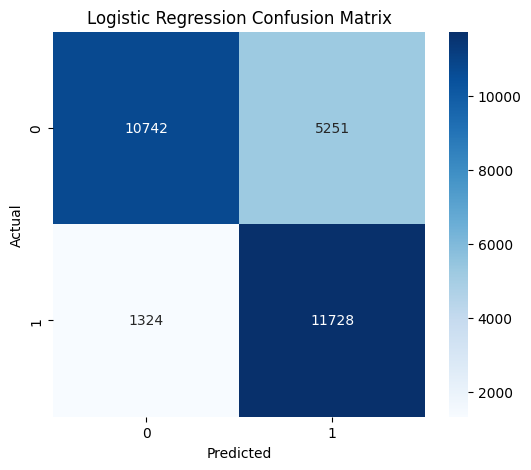

In [9]:
cm = confusion_matrix(y_test, lr_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Store Model Performance

In [10]:
results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1
})
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.773627,0.690736,0.89856,0.78106


## Decision Tree

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_prediction = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_prediction)
dt_precision = precision_score(y_test, dt_prediction)
dt_recall = recall_score(y_test, dt_prediction)
dt_f1 = f1_score(y_test, dt_prediction)

print("Accuracy :", dt_accuracy)
print("Precision :", dt_precision)
print("Recall :", dt_recall)
print("F1 Score :", dt_f1)

results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1
})

Accuracy : 0.8769839903597866
Precision : 0.8647171989226625
Recall : 0.8609408519767086
F1 Score : 0.862824893461819


## Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)
rf_precision = precision_score(y_test, rf_prediction)
rf_recall = recall_score(y_test, rf_prediction)
rf_f1 = f1_score(y_test, rf_prediction)

print("Accuracy :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall :", rf_recall)
print("F1 Score :", rf_f1)

results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1
})

Accuracy : 0.896574281287657
Precision : 0.8828684651729919
Recall : 0.8876034324241495
F1 Score : 0.8852296171773516


## Extra Trees

In [13]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

et_prediction = et.predict(X_test)

et_accuracy = accuracy_score(y_test, et_prediction)
et_precision = precision_score(y_test, et_prediction)
et_recall = recall_score(y_test, et_prediction)
et_f1 = f1_score(y_test, et_prediction)

print("Accuracy :", et_accuracy)
print("Precision :", et_precision)
print("Recall :", et_recall)
print("F1 Score :", et_f1)

results.append({
    "Model": "Extra Trees",
    "Accuracy": et_accuracy,
    "Precision": et_precision,
    "Recall": et_recall,
    "F1 Score": et_f1
})

Accuracy : 0.8910311585470821
Precision : 0.8748767725790552
Recall : 0.8839258351210543
F1 Score : 0.8793780250771752


## Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


## K-Nearest Neighbors

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)

knn_prediction = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_prediction)
knn_precision = precision_score(y_test, knn_prediction)
knn_recall = recall_score(y_test, knn_prediction)
knn_f1 = f1_score(y_test, knn_prediction)

print("Accuracy :", knn_accuracy)
print("Precision :", knn_precision)
print("Recall :", knn_recall)
print("F1 Score :", knn_f1)

results.append({
    "Model": "K-Nearest Neighbors",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1 Score": knn_f1
})

Accuracy : 0.8592184541229128
Precision : 0.8373353406097102
Recall : 0.8522831749923383
F1 Score : 0.8447431370315526


## Gaussian Naive Bayes

In [16]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

nb_prediction = nb.predict(X_test_scaled)

nb_accuracy = accuracy_score(y_test, nb_prediction)
nb_precision = precision_score(y_test, nb_prediction)
nb_recall = recall_score(y_test, nb_prediction)
nb_f1 = f1_score(y_test, nb_prediction)

print("Accuracy :", nb_accuracy)
print("Precision :", nb_precision)
print("Recall :", nb_recall)
print("F1 Score :", nb_f1)

results.append({
    "Model": "Gaussian Naive Bayes",
    "Accuracy": nb_accuracy,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1 Score": nb_f1
})

Accuracy : 0.7635049061800654
Precision : 0.6982874735424284
Recall : 0.8341250383083052
F1 Score : 0.7601857347344901


## Linear Support Vector Machine

In [17]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm.fit(X_train_scaled, y_train)

svm_prediction = svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_prediction)
svm_precision = precision_score(y_test, svm_prediction)
svm_recall = recall_score(y_test, svm_prediction)
svm_f1 = f1_score(y_test, svm_prediction)

print("Accuracy :", svm_accuracy)
print("Precision :", svm_precision)
print("Recall :", svm_recall)
print("F1 Score :", svm_f1)

results.append({
    "Model": "Linear SVM",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1 Score": svm_f1
})

Accuracy : 0.7330005164400069
Precision : 0.6351344456349813
Recall : 0.953723567269384
F1 Score : 0.7624881320633365


## AdaBoost

In [18]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

ada_prediction = ada.predict(X_test)

ada_accuracy = accuracy_score(y_test, ada_prediction)
ada_precision = precision_score(y_test, ada_prediction)
ada_recall = recall_score(y_test, ada_prediction)
ada_f1 = f1_score(y_test, ada_prediction)

print("Accuracy :", ada_accuracy)
print("Precision :", ada_precision)
print("Recall :", ada_recall)
print("F1 Score :", ada_f1)

results.append({
    "Model": "AdaBoost",
    "Accuracy": ada_accuracy,
    "Precision": ada_precision,
    "Recall": ada_recall,
    "F1 Score": ada_f1
})

Accuracy : 0.84981924599759
Precision : 0.7900921351315262
Recall : 0.9066809684339565
F1 Score : 0.844381020335355


## Gradient Boosting

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train, y_train)

gb_prediction = gb.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_prediction)
gb_precision = precision_score(y_test, gb_prediction)
gb_recall = recall_score(y_test, gb_prediction)
gb_f1 = f1_score(y_test, gb_prediction)

print("Accuracy :", gb_accuracy)
print("Precision :", gb_precision)
print("Recall :", gb_recall)
print("F1 Score :", gb_f1)

results.append({
    "Model": "Gradient Boosting",
    "Accuracy": gb_accuracy,
    "Precision": gb_precision,
    "Recall": gb_recall,
    "F1 Score": gb_f1
})

Accuracy : 0.8868652091582028
Precision : 0.8448446327683616
Recall : 0.9165645111860251
F1 Score : 0.8792444509775099


## HistGradientBoosting

In [20]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=100,
    random_state=42
)

hgb.fit(X_train, y_train)

hgb_prediction = hgb.predict(X_test)

hgb_accuracy = accuracy_score(y_test, hgb_prediction)
hgb_precision = precision_score(y_test, hgb_prediction)
hgb_recall = recall_score(y_test, hgb_prediction)
hgb_f1 = f1_score(y_test, hgb_prediction)

print("Accuracy :", hgb_accuracy)
print("Precision :", hgb_precision)
print("Recall :", hgb_recall)
print("F1 Score :", hgb_f1)

results.append({
    "Model": "HistGradientBoosting",
    "Accuracy": hgb_accuracy,
    "Precision": hgb_precision,
    "Recall": hgb_recall,
    "F1 Score": hgb_f1
})

Accuracy : 0.8970907212945429
Precision : 0.8768631563178788
Recall : 0.8969506589028501
F1 Score : 0.8867931674430936


## Model Performance Comparison

In [21]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,HistGradientBoosting,0.897091,0.876863,0.896951,0.886793
1,Random Forest,0.896574,0.882868,0.887603,0.885230
2,Extra Trees,0.891031,0.874877,0.883926,0.879378
3,Gradient Boosting,0.886865,0.844845,0.916565,0.879244
4,Decision Tree,0.876984,0.864717,0.860941,0.862825
5,K-Nearest Neighbors,0.859218,0.837335,0.852283,0.844743
6,AdaBoost,0.849819,0.790092,0.906681,0.844381
7,Logistic Regression,0.773627,0.690736,0.898560,0.781060
8,Linear SVM,0.733001,0.635134,0.953724,0.762488
9,Gaussian Naive Bayes,0.763505,0.698287,0.834125,0.760186


## Model Accuracy Comparison

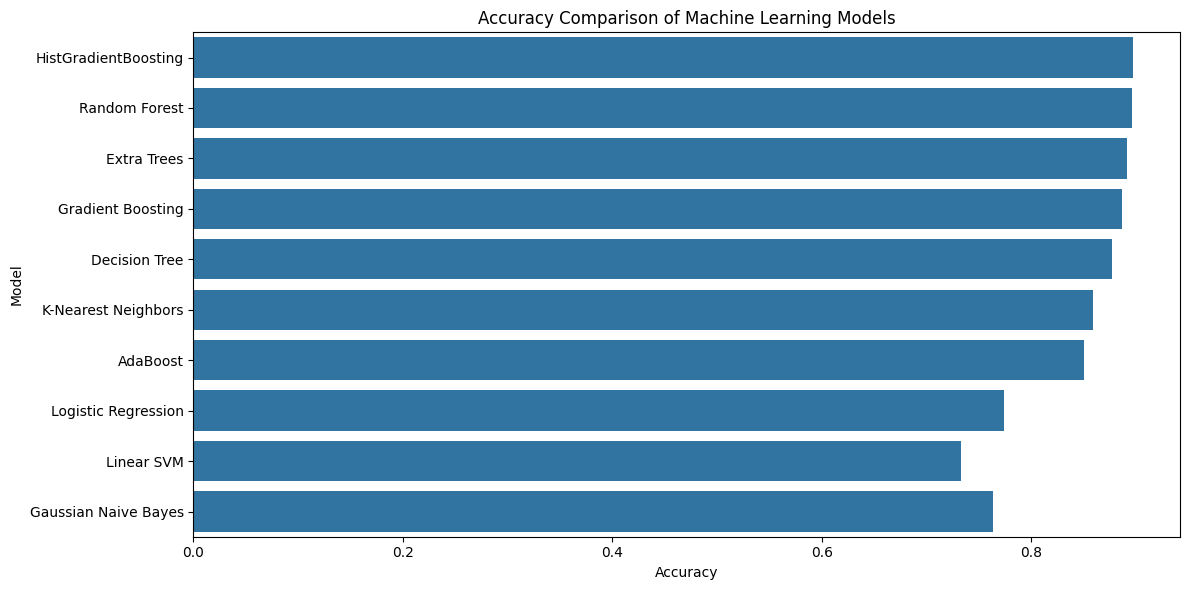

In [22]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xlabel("Accuracy")

plt.ylabel("Model")

plt.tight_layout()

plt.show()

## F1 Score Comparison

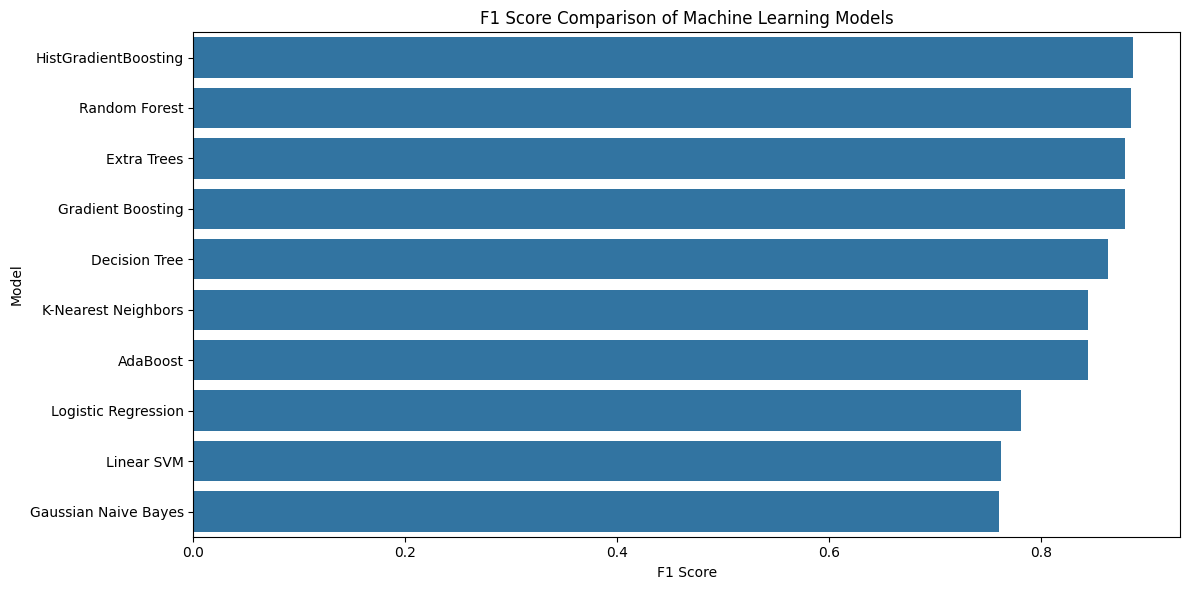

In [23]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model"
)
plt.title("F1 Score Comparison of Machine Learning Models")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## Stage 2: Attack Classification

In [24]:
attack_data = data[data["label"] == 1].copy()

print("Attack Dataset Shape:", attack_data.shape)

attack_data["attack_cat"].value_counts()

Attack Dataset Shape: (65257, 17)


attack_cat
3    26749
4    18313
7     8012
2     4873
5     3057
0     1442
1     1389
8     1257
9      165
Name: count, dtype: int64

## Prepare Attack Classification Dataset

In [25]:
X_attack = attack_data.drop(["label", "attack_cat"], axis=1)

y_attack = attack_data["attack_cat"]

print("Features Shape :", X_attack.shape)
print("Target Shape :", y_attack.shape)

Features Shape : (65257, 15)
Target Shape : (65257,)


## Encode Attack Categories

In [26]:
from sklearn.preprocessing import LabelEncoder

attack_encoder = LabelEncoder()

y_attack_encoded = attack_encoder.fit_transform(y_attack)

print("Attack Categories:")
print(attack_encoder.classes_)

Attack Categories:
[0 1 2 3 4 5 7 8 9]


## Split Attack Classification Dataset

In [27]:
X_attack_train, X_attack_test, y_attack_train, y_attack_test = train_test_split(
    X_attack,
    y_attack_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_attack_encoded
)

print("Training Data :", X_attack_train.shape)
print("Testing Data :", X_attack_test.shape)

Training Data : (52205, 15)
Testing Data : (13052, 15)


## Train Random Forest for Attack Classification

In [28]:
attack_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

attack_rf.fit(X_attack_train, y_attack_train)

attack_prediction = attack_rf.predict(X_attack_test)

attack_accuracy = accuracy_score(
    y_attack_test,
    attack_prediction
)

print("Attack Classification Accuracy :", attack_accuracy)

Attack Classification Accuracy : 0.7436408213300644


## Attack Classification Report

In [29]:
print(
    classification_report(
        y_attack_test,
        attack_prediction,
        labels=range(len(attack_encoder.classes_)),
        target_names=[str(x) for x in attack_encoder.classes_],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.21      0.26      0.23       288
           1       0.37      0.16      0.22       278
           2       0.28      0.20      0.24       975
           3       0.78      0.87      0.82      5350
           4       0.82      0.86      0.84      3663
           5       0.88      0.62      0.72       611
           7       0.79      0.72      0.76      1603
           8       0.35      0.23      0.27       251
           9       0.31      0.15      0.20        33

    accuracy                           0.74     13052
   macro avg       0.53      0.45      0.48     13052
weighted avg       0.73      0.74      0.73     13052



## Attack Classification Confusion Matrix

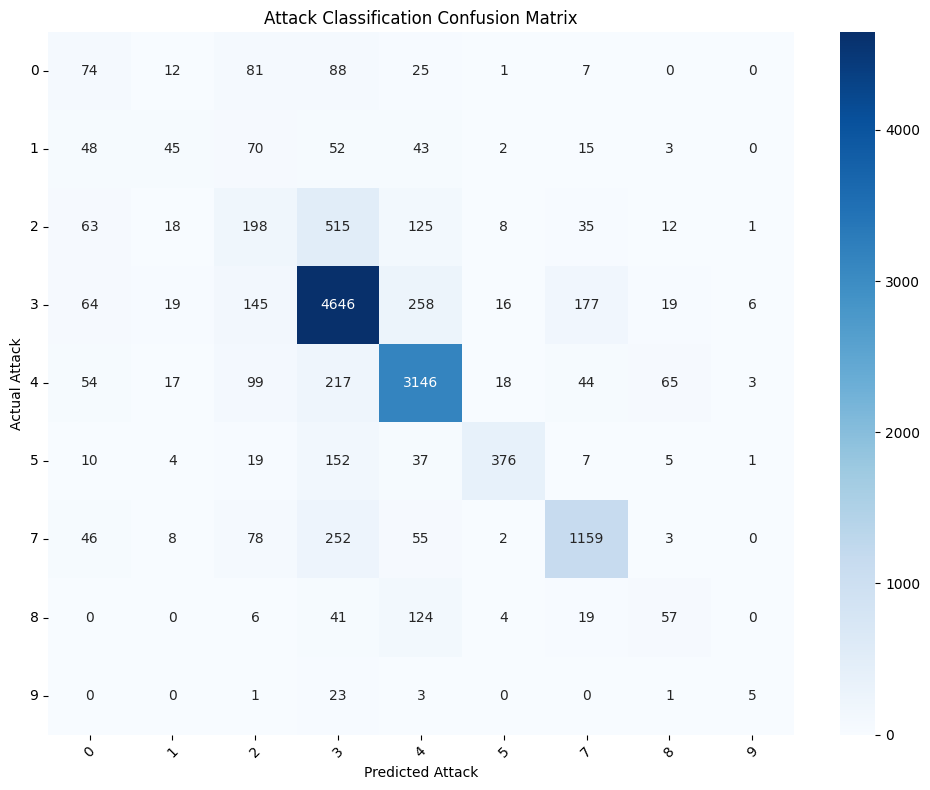

In [30]:
cm_attack = confusion_matrix(
    y_attack_test,
    attack_prediction
)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_attack,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=attack_encoder.classes_,
    yticklabels=attack_encoder.classes_
)
plt.title("Attack Classification Confusion Matrix")
plt.xlabel("Predicted Attack")
plt.ylabel("Actual Attack")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Attack Classification Results

In [31]:
attack_results = pd.DataFrame({
    "Actual": attack_encoder.inverse_transform(y_attack_test),
    "Predicted": attack_encoder.inverse_transform(attack_prediction)
})

attack_results.head(20)

,Actual,Predicted
0,7,7
1,7,7
2,3,3
3,3,3
4,4,4
5,3,3
6,3,3
7,4,8
8,0,3
9,7,7


## Attack Category Distribution

In [32]:
visualization_data = pd.read_csv(
    "../visualization/visualization_dataset.csv"
)
attack_category_counts = visualization_data[
    visualization_data["label"] == 1
]["attack_cat"].value_counts()

print(attack_category_counts)

attack_cat
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


## Attack Category Visualization

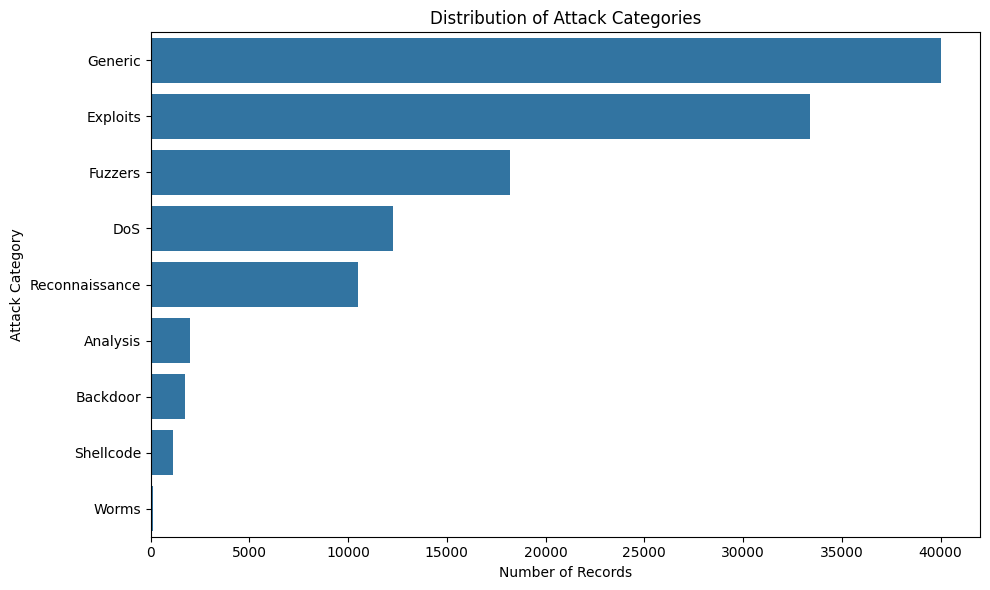

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=attack_category_counts.values,
    y=attack_category_counts.index
)

plt.title("Distribution of Attack Categories")

plt.xlabel("Number of Records")

plt.ylabel("Attack Category")

plt.tight_layout()

plt.show()

## Attack Classification Model Performance

In [34]:
attack_precision = precision_score(
    y_attack_test,
    attack_prediction,
    average="weighted",
    zero_division=0
)

attack_recall = recall_score(
    y_attack_test,
    attack_prediction,
    average="weighted",
    zero_division=0
)

attack_f1 = f1_score(
    y_attack_test,
    attack_prediction,
    average="weighted",
    zero_division=0
)

print("Accuracy :", attack_accuracy)
print("Precision :", attack_precision)
print("Recall :", attack_recall)
print("F1 Score :", attack_f1)

Accuracy : 0.7436408213300644
Precision : 0.72902501304544
Recall : 0.7436408213300644
F1 Score : 0.7321687576980453


## Save Attack Classification Model

In [35]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    attack_rf,
    "../models/cybershield_attack_classifier.pkl"
)

joblib.dump(
    attack_encoder,
    "../models/attack_category_encoder.pkl"
)

print("Attack classification model saved successfully.")

Attack classification model saved successfully.


## Save Detection Model

In [36]:
joblib.dump(
    best_hgb if "best_hgb" in globals() else hgb,
    "../models/cybershield_detection_model.pkl"
)

print("Detection model saved successfully.")

Detection model saved successfully.


## Save Selected Features

In [37]:
selected_features = [
    col for col in data.columns
    if col not in ["label", "attack_cat"]
]

joblib.dump(
    selected_features,
    "../models/selected_features.pkl"
)

print("Selected features saved successfully.")
print("Number of selected features:", len(selected_features))

Selected features saved successfully.
Number of selected features: 15


## Generate Detection and Classification Predictions

In [38]:
sample_data = X_test.iloc[:10].copy()

sample_detection = hgb.predict(sample_data)

attack_samples = sample_data[sample_detection == 1]

print("Total Samples :", len(sample_data))
print("Attacks Detected :", len(attack_samples))

Total Samples : 10
Attacks Detected : 5


## Classify Detected Attacks

In [39]:
if len(attack_samples) > 0:
    sample_attack_prediction = attack_rf.predict(attack_samples)

    sample_attack_names = attack_encoder.inverse_transform(
        sample_attack_prediction
    )

    print("Detected Attack Types:")
    print(sample_attack_names)
else:
    print("No attacks detected.")

Detected Attack Types:
[7 7 4 5 7]


## Create Prediction Results

In [40]:
prediction_results = pd.DataFrame({
    "Detection": sample_detection
})

prediction_results["Detection"] = prediction_results["Detection"].map({
    0: "Normal",
    1: "Attack"
})

prediction_results

,Detection
0,Attack
1,Normal
2,Attack
3,Normal
4,Normal
5,Normal
6,Normal
7,Attack
8,Attack
9,Attack


## Add Attack Type to Predictions

In [41]:
all_attack_names = [
    "Analysis",
    "Backdoor",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
    "Shellcode",
    "Worms"
]

attack_name_mapping = {
    i: name for i, name in enumerate(all_attack_names)
}

print("Attack Category Mapping:")
print(attack_name_mapping)

Attack Category Mapping:
{0: 'Analysis', 1: 'Backdoor', 2: 'DoS', 3: 'Exploits', 4: 'Fuzzers', 5: 'Generic', 6: 'Reconnaissance', 7: 'Shellcode', 8: 'Worms'}


## Convert Predictions to Attack Names

In [42]:
prediction_results["Attack Type"] = "Normal"

if len(attack_samples) > 0:

    predicted_names = [
        attack_name_mapping.get(int(pred), "Unknown")
        for pred in sample_attack_prediction
    ]

    prediction_results.loc[
        prediction_results["Detection"] == "Attack",
        "Attack Type"
    ] = predicted_names

prediction_results

,Detection,Attack Type
0,Attack,Reconnaissance
1,Normal,Normal
2,Attack,Reconnaissance
3,Normal,Normal
4,Normal,Normal
5,Normal,Normal
6,Normal,Normal
7,Attack,Fuzzers
8,Attack,Generic
9,Attack,Reconnaissance
